# Assignment 3: Tree-based Methods, PCA, KNN and SVM

> STAT3612, 2025 Fall

In [6]:
import pandas as pd

df = pd.read_csv("./heart.csv")

In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
df['newSex'] = df['Sex'].map({'M': 1,'F': 0})
df['newChestPainType'] = df['ChestPainType'].map({'ASY':3, 'NAP':2, 'ATA': 1,'TA': 0})
df['newRestingECG'] = df['RestingECG'].map({'LVH':2, 'ST': 1,'Normal': 0})
df['newExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1,'N': 0})
df['newST_Slope'] = df['ST_Slope'].map({'Down':2, 'Up': 1,'Flat': 0})
df.drop('Sex', axis=1, inplace=True)
df.drop('ChestPainType', axis=1, inplace=True)
df.drop('RestingECG', axis=1, inplace=True)
df.drop('ExerciseAngina', axis=1, inplace=True)
df.drop('ST_Slope', axis=1, inplace=True)
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,newSex,newChestPainType,newRestingECG,newExerciseAngina,newST_Slope
0,40,140,289,0,172,0.0,0,1,1,0,0,1
1,49,160,180,0,156,1.0,1,0,2,0,0,0
2,37,130,283,0,98,0.0,0,1,1,1,0,1
3,48,138,214,0,108,1.5,1,0,3,0,1,0
4,54,150,195,0,122,0.0,0,1,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,1,0,0,0,0
914,68,144,193,1,141,3.4,1,1,3,0,0,0
915,57,130,131,0,115,1.2,1,1,3,0,1,0
916,57,130,236,0,174,0.0,1,0,1,2,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   newSex             918 non-null    int64  
 8   newChestPainType   918 non-null    int64  
 9   newRestingECG      918 non-null    int64  
 10  newExerciseAngina  918 non-null    int64  
 11  newST_Slope        918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [10]:
X=df.drop('HeartDisease',axis=1)
Y=df['HeartDisease']

#### Part 1: Tree-based Methods

In [11]:
# Q1 (a)

# ------------------
# Write your code here

from sklearn.model_selection import train_test_split

# 测试集占40%，随机种子设为2025(保证每次分的一样)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=2025)

print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

# ------------------

训练集大小: (550, 11)
测试集大小: (368, 11)


In [24]:
# Q1 (b)

# ------------------
# Write your code here

from sklearn.preprocessing import MinMaxScaler

# 缩放器
scaler = MinMaxScaler(feature_range=(-1, 1))

# 计算标准并缩放
X_train = scaler.fit_transform(X_train)

# 2. 用同样的标准去缩放测试集 (注意这里只用 transform，不用 fit)
X_test = scaler.transform(X_test)

# ------------------

In [13]:
# Q1 (c)

# ------------------
# Write your code here

from sklearn.tree import DecisionTreeClassifier

# 最大深度设为3（只能问3层问题）
dt_clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=2025)
dt_clf.fit(X_train, y_train)

# ------------------

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


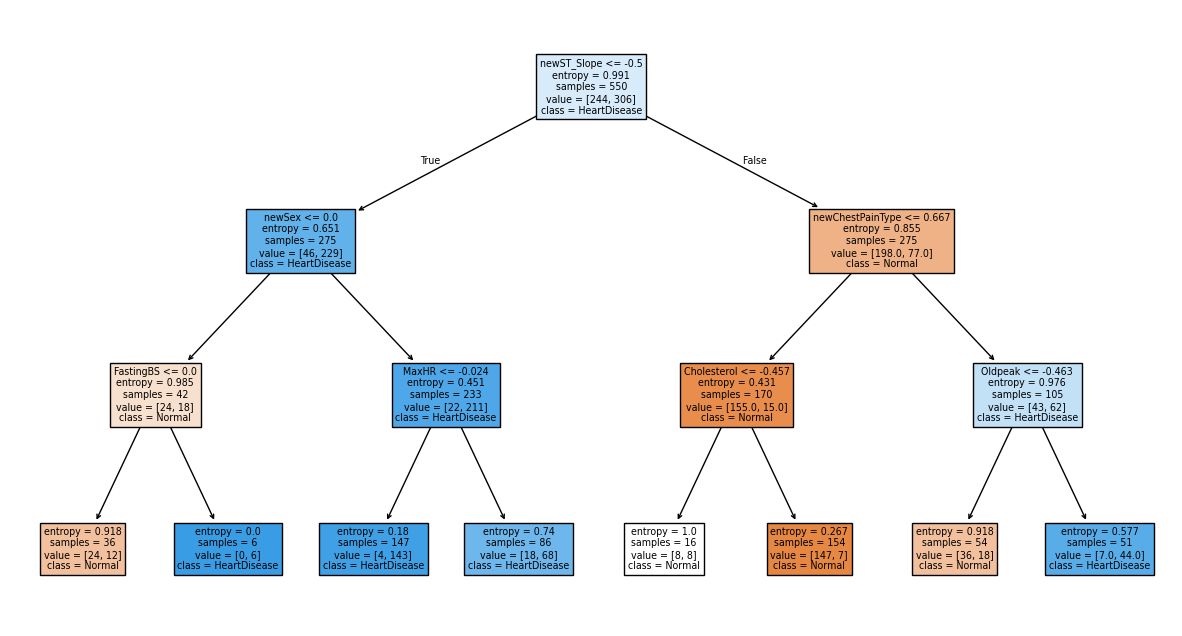

训练集准确率 (Train Accuracy): 0.8655
测试集准确率 (Test Accuracy): 0.8234


In [14]:
# Q1 (d)

# ------------------
# Write your code here

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))
plot_tree(dt_clf, feature_names=X.columns, class_names=['Normal', 'HeartDisease'], filled=True)
plt.show()

train_score = dt_clf.score(X_train, y_train)
test_score = dt_clf.score(X_test, y_test)

print(f"训练集准确率 (Train Accuracy): {train_score:.4f}")
print(f"测试集准确率 (Test Accuracy): {test_score:.4f}")

# ------------------

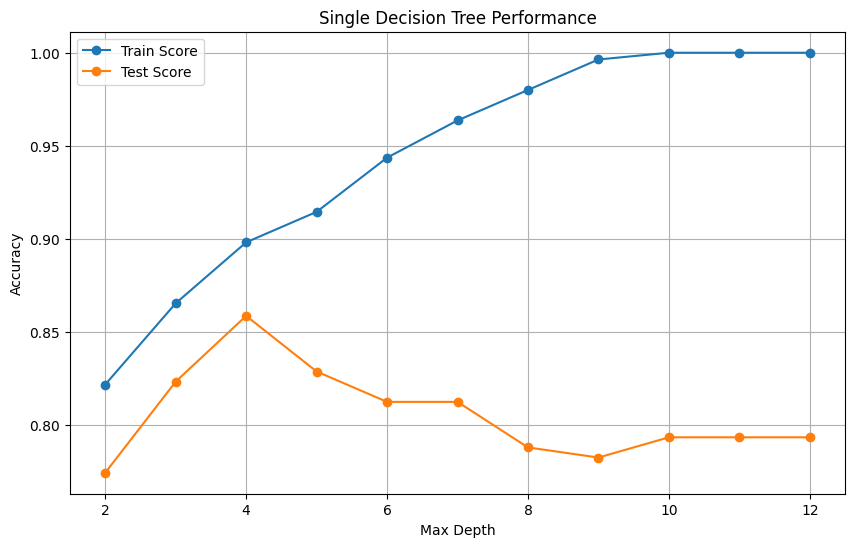

测试集最高分是: 0.8587，发生在深度: 4


In [15]:
# Q2 (a)

# ------------------
# Write your code here

train_scores = []
test_scores = []
depths = range(2, 13)

for d in depths:
    # 建立对应深度的树
    clf = DecisionTreeClassifier(max_depth=d, criterion='entropy', random_state=2025)
    clf.fit(X_train, y_train)
    
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Score', marker='o')
plt.plot(depths, test_scores, label='Test Score', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Single Decision Tree Performance')
plt.legend()
plt.grid(True)
plt.show()

max_score = max(test_scores)
best_depth = depths[test_scores.index(max_score)]
print(f"测试集最高分是: {max_score:.4f}，发生在深度: {best_depth}")

# ------------------

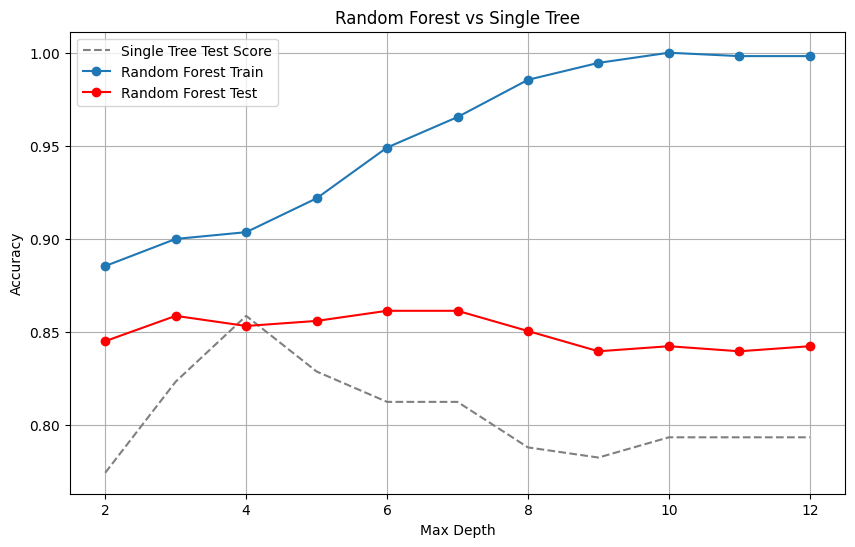

随机森林最高分是: 0.8614，发生在深度: 6


In [16]:
# Q2 (b)

# ------------------
# Write your code here

from sklearn.ensemble import RandomForestClassifier

rf_train_scores = []
rf_test_scores = []

for d in depths:
    rf = RandomForestClassifier(n_estimators=80, max_features=4, max_depth=d, random_state=2025)
    rf.fit(X_train, y_train)
    
    rf_train_scores.append(rf.score(X_train, y_train))
    rf_test_scores.append(rf.score(X_test, y_test))

# 单棵树的成绩(Q2a)和现在森林的成绩放在一起
plt.figure(figsize=(10, 6))
plt.plot(depths, test_scores, label='Single Tree Test Score', linestyle='--', color='gray') # 上一题的树
plt.plot(depths, rf_train_scores, label='Random Forest Train', marker='o')
plt.plot(depths, rf_test_scores, label='Random Forest Test', marker='o', color='red')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest vs Single Tree')
plt.legend()
plt.grid(True)
plt.show()

max_rf_score = max(rf_test_scores)
best_rf_depth = depths[rf_test_scores.index(max_rf_score)]
print(f"随机森林最高分是: {max_rf_score:.4f}，发生在深度: {best_rf_depth}")

# ------------------

#### Part 3: PCA and K-Nearest Neighbors

In [17]:
# Q3 (a)

# ------------------
# Write your code here

from sklearn.neighbors import KNeighborsClassifier

# 建立KNN模型 (默认看周围5个邻居)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# 打印分数
print(f"KNN 测试集准确率: {knn.score(X_test, y_test):.4f}")

# ------------------

KNN 测试集准确率: 0.8288


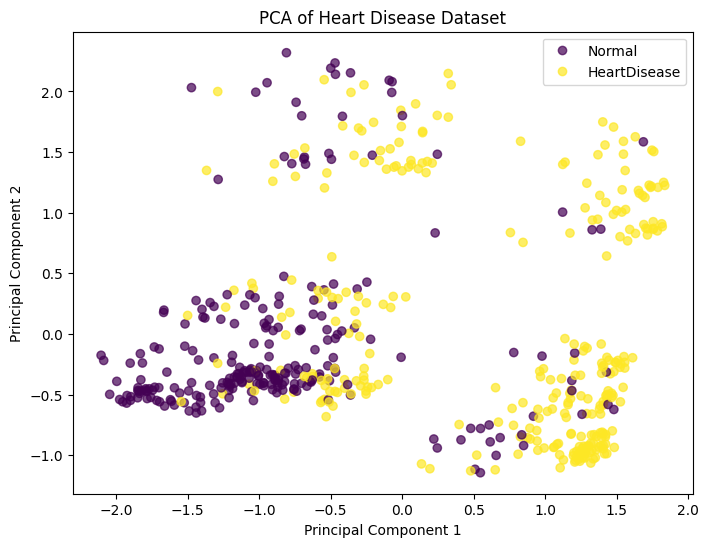

In [18]:
# Q3 (b)

# ------------------
# Write your code here

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 散点图
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Heart Disease Dataset')
plt.legend(handles=scatter.legend_elements()[0], labels=['Normal', 'HeartDisease'])
plt.show()

# ------------------

In [19]:
# Q3 (c)

# ------------------
# Write your code here

# 用压缩后的数据训练KNN
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, y_train)

pca_score = knn_pca.score(X_test_pca, y_test)
print(f"PCA处理后的 KNN 准确率: {pca_score:.4f}")

# 比较
print("原来的准确率更高" if knn.score(X_test, y_test) > pca_score else "PCA后的准确率更高")

# ------------------

PCA处理后的 KNN 准确率: 0.8071
原来的准确率更高


#### Part 4: Support Vector Machine

In [20]:
# Q4 (a)

# ------------------
# Write your code here

from sklearn.preprocessing import StandardScaler
import numpy as np

X_svm_raw = df[['Age', 'RestingBP']].values
y_svm = df['HeartDisease'].values

# 标准化
scaler_svm = StandardScaler()
X_svm_scaled = scaler_svm.fit_transform(X_svm_raw)

# ------------------

In [21]:
# Q4 (b)

# ------------------
# Write your code here

from sklearn.svm import SVC

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_svm_scaled, y_svm, test_size=0.3, random_state=2025
)

svc_model = SVC(C=1.5, kernel='rbf')
svc_model.fit(X_train_s, y_train_s)

# ------------------

,C,1.5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


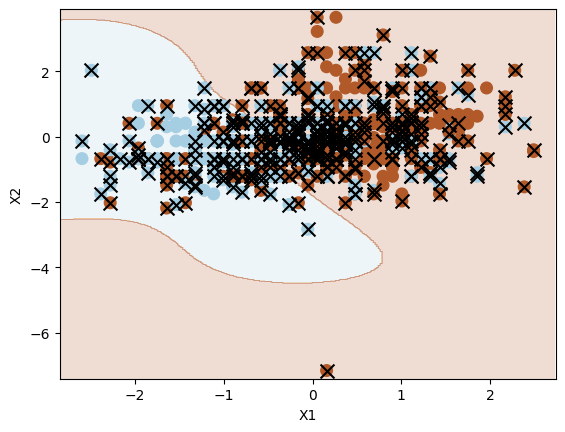

Number of support vectors:  503
支持向量总数: 503


In [22]:
# Q4 (c)

# ------------------

import matplotlib as mpl

def plot_svc(svc, X, y, h=0.02, pad=0.25):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.2)

    plt.scatter(X[:, 0], X[:, 1], s=70, c=y, cmap=mpl.cm.Paired)
    # Support vectors indicated in plot by vertical lines
    sv = svc.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], c='k', marker='x', s=100)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()
    print('Number of support vectors: ', svc.support_.size)

# Write your code here

plot_svc(svc_model, X_train_s, y_train_s)

print(f"支持向量总数: {svc_model.support_.size}")

# ------------------

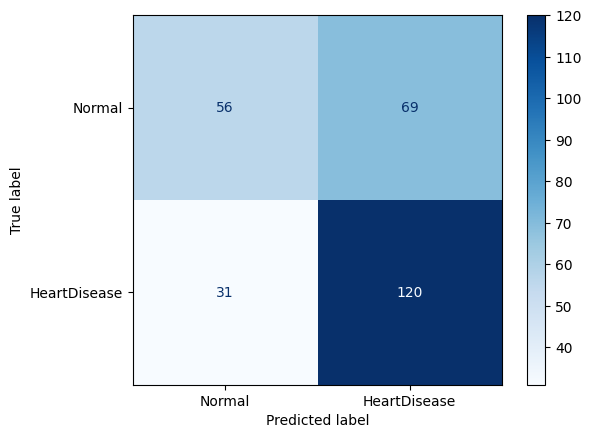

SVM 测试集准确率: 0.6377


In [23]:
# Q4 (d)

# ------------------
# Write your code here

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 预测测试集
y_pred_s = svc_model.predict(X_test_s)

cm = confusion_matrix(y_test_s, y_pred_s)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'HeartDisease'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(f"SVM 测试集准确率: {svc_model.score(X_test_s, y_test_s):.4f}")

# ------------------